$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.6

## 理论

再次考察式 (2.1) 中的同一一元函数，不过此时数据由下式生成：

$$
y_i = h(x_i) + \epsilon_i,\quad i = 1, \dots, n \tag{2.29}
$$

式中 $\epsilon_i$ 为其余未观测变量发生变动或是测量误差所带来的随机误差。假定通过开展 $n=20$ 次实验生成数据，实验设计选取区间 $[0,1]$ 内等间距分布的 10 个采样点，每个采样点重复实验两次。图 2.6 中绘制了测试函数（黑色虚线）与数据集 $\{(x_i, y_i)\}_{i=1}^{20}$（蓝色圆点）。

假设我们希望借助多项式

$$
y = \beta_0 + \beta_1x + \dots + \beta_mx^m
\tag{2.30}
$$

来近似函数 $h(x)$。线性回归方法将上述多项式视作真实模型，并假定数据由下式生成：

$$
y_i = \beta_0 + \beta_1x_i + \dots + \beta_mx_i^m + \epsilon_i,\quad i = 1,\dots,n
\tag{2.31}
$$

而非式 (2.29)。因此该方法忽略了多项式逼近 $h(x)$ 带来的偏差。我们可以选取合适的参数，让拟合模型尽可能贴合实测数据。可以选用多种损失函数衡量模型与数据的“贴合程度”，其中最简单的是平方误差损失：

$$
\min_{\boldsymbol{\beta}} \sum_{i=1}^n \left\{y_i - [\beta_0 + \dots + \beta_mx_i^m]\right\}^2
$$

采用矩阵形式表述该优化问题：

$$
\min_{\boldsymbol{\beta}} (\boldsymbol{y} - \boldsymbol{X}\boldsymbol{\beta})'(\boldsymbol{y} - \boldsymbol{X}\boldsymbol{\beta})
$$

其中矩阵 $\boldsymbol{X}=\{x_i^{j-1}\}$ 是维度为 $n\times(m+1)$ 的模型设计矩阵。将目标函数对 $\boldsymbol{\beta}$ 求导并令导数等于零，可得正规方程：

$$
\boldsymbol{X}'\boldsymbol{X}\boldsymbol{\beta} = \boldsymbol{X}'\boldsymbol{y}
$$

若 $\boldsymbol{X}'\boldsymbol{X}$ 为非奇异矩阵，则存在唯一解：

$$
\hat{\boldsymbol{\beta}} = (\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{X}'\boldsymbol{y}
\tag{2.32}
$$

在本例一维场景中，自变量 $x$ 仅有 10 个互不相同的采样点，想要保证矩阵 $\boldsymbol{X}$ 的列向量线性无关，多项式阶数 $m$ 必须满足 $m\le9$。

预测函数 $\hat{y}(x) = \boldsymbol{x}'\hat{\boldsymbol{\beta}}$（其中 $\boldsymbol{x} = (1, x, \dots, x_m)'$）在阶数 $m=3$ 与 $m=8$ 时的拟合曲线，在图 2.6 中以绿色实线绘制。相较于八次多项式拟合，三次多项式拟合在观测点处产生的偏差更大。但整体拟合效果上，三次多项式的拟合效果并不逊色于八次多项式，甚至表现更佳。

由于 $\boldsymbol{y}=\boldsymbol{X}\boldsymbol{\beta}+\boldsymbol{\epsilon}$ 服从正态分布，设 $\boldsymbol{\epsilon}$ 也服从正态分布，因此 $\boldsymbol{\beta}$ 也服从正态分布，则均值为

$$
\begin{align*}
E(\hat{\boldsymbol{\beta}})&=(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{X}'E(\boldsymbol{y})\\
&=(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{X}'\boldsymbol{X}\boldsymbol{\beta}=\boldsymbol{\beta}
\end{align*}
$$

协方差矩阵为

$$
\begin{align*}
cov(\hat{\boldsymbol{\beta}})&=cov\{(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{X}'\boldsymbol{y}\}\\
&=(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{X}'cov(\boldsymbol{y})\boldsymbol{X}(\boldsymbol{X}'\boldsymbol{X})^{-1}\\
&=(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{X}'\sigma^2\boldsymbol{I}\boldsymbol{X}(\boldsymbol{X}'\boldsymbol{X})^{-1}\\
&=\sigma^2(\boldsymbol{X}'\boldsymbol{X})^{-1}
\end{align*}
$$

再进一步假设 $\epsilon_i$ 独立同分布，满足 $\epsilon_i\sim \mathcal{N}(0, \sigma^2)，i = 1, \dots, n$，不难证明：

$$
\hat{\boldsymbol{\beta}} \sim \mathcal{N}\left(\boldsymbol{\beta},\sigma^2(\boldsymbol{X}'\boldsymbol{X})^{-1}\right)
\tag{2.33}
$$

据此可求得预测值的方差：

$$
var\{\hat{y}(\boldsymbol{x})\} = var\{\boldsymbol{x}'\hat{\boldsymbol{\beta}}\} = \sigma^2\boldsymbol{x}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}
$$

该方差仅体现参数 $\boldsymbol{\beta}$ 估计过程带来的不确定性。由此可得新观测值预测结果的 95% 置信区间：

$$
\hat{y}(\boldsymbol{x}) \pm 2\sigma\sqrt{1 + \boldsymbol{x}'(\boldsymbol{X}'\boldsymbol{X})^{-1}\boldsymbol{x}}
$$

式中在原有方差基础上额外增加一项 $\sigma^2$，用以刻画新增扰动项 $\epsilon$ 带来的不确定性，该置信区间在图 2.6 中以阴影区域呈现。可以发现，三次多项式拟合对应的置信区间比八次多项式拟合的置信区间更窄，但三次多项式拟合在观测数据点附近存在更大的偏差；因此更窄的置信区间并不代表其预测精度更高。

## 实践

创建画布宽 20 英寸、高 10 英寸，将画布分为 1x2。依据公式

$$
h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]
\tag{2.1}
$$

定义函数 f(x)。令 N=301，在 $[0,1]$ 上等距选取 N 个点作为绘图点的横坐标，令其为 test，并计算 f(test) 作为绘图点的纵坐标，令其为 ture。令 n=10，依据均匀区间端点公式

$$
D=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
$$

取 1:n 上的等距 n 个点作为观测点的横坐标，命名为 D。令 r=2，将 D 重复 r 次作为每个点分别进行两次观测的点的横坐标，仍然令其为 D。设置种子为 1，从正态分布 $\mathcal{N}(0,0.1)$ 上随机选取 n*r 个点作为每次观测的误差，令其为 e。计算每个点对应的函数值作为点的纵坐标，再加上误差 e 作为含噪声的观测点的纵坐标，命名为 y。

绘制真实函数的图像，其中类型为 l，线型为 2，线宽为 4，x 轴标签为 x，y 轴标签为 y，大小为 2，y 轴范围为 c(min(true)-.25,max(true)+.25)，大小为 2，图像标题为“三次多项式回归 (等距节点)”，大小为 2。叠加观测点，其中点型为 16，大小为 3，颜色为蓝色。令 i=3，调用 lm() 函数对 y 拟合三次多项式 poly(D,i) 回归模型，并利用 predict() 函数计算预测值及其置信区间，其中数据集为 data.frame(D=test)，即将 test 封装为数据框，列名命名为 D，区间选择预测区间 confidence，将返回的预测列表命名为 pred，其中第 1 列为预测均值，第 2，3 列为预测区间的下上界。绘制预测值的图像，其中颜色为 3，线宽为 5。绘制置信区间的图像，其中颜色为 20% 的红色，无边框。添加图例，其中位置为 (.25,-.4)，图例内容为“真实值”和“预测值”，线型分别为 2 和 1，颜色分别为 1 和 3，线宽分别为 3 和 4，无边框，大小为 2。

绘制真实函数的图像，其中类型为 l，线型为 2，线宽为 4，x 轴标签为 x，y 轴标签为 y，大小为 2，y 轴范围为 c(min(true)-.25,max(true)+.25)，大小为 2，图像标题为“八次多项式回归 (等距节点)”，大小为 2。叠加观测点，其中点型为 16，大小为 3，颜色为蓝色。令 i=8，调用 lm() 函数对 y 拟合八次多项式 poly(D,i) 回归模型，并利用 predict() 函数计算预测值及其置信区间，其中数据集为 data.frame(D=test)，即将 test 封装为数据框，列名命名为 D，区间选择预测区间 confidence，将返回的预测列表命名为 pred，其中第 1 列为预测均值，第 2，3 列为预测区间的下上界。绘制预测值的图像，其中颜色为 3，线宽为 5。绘制置信区间的图像，其中颜色为 20% 的红色，无边框。添加图例，其中位置为 (.25,-.4)，图例内容为“真实值”和“预测值”，线型分别为 2 和 1，颜色分别为 1 和 3，线宽分别为 3 和 4，无边框，大小为 2。将画布还原回 1x1。

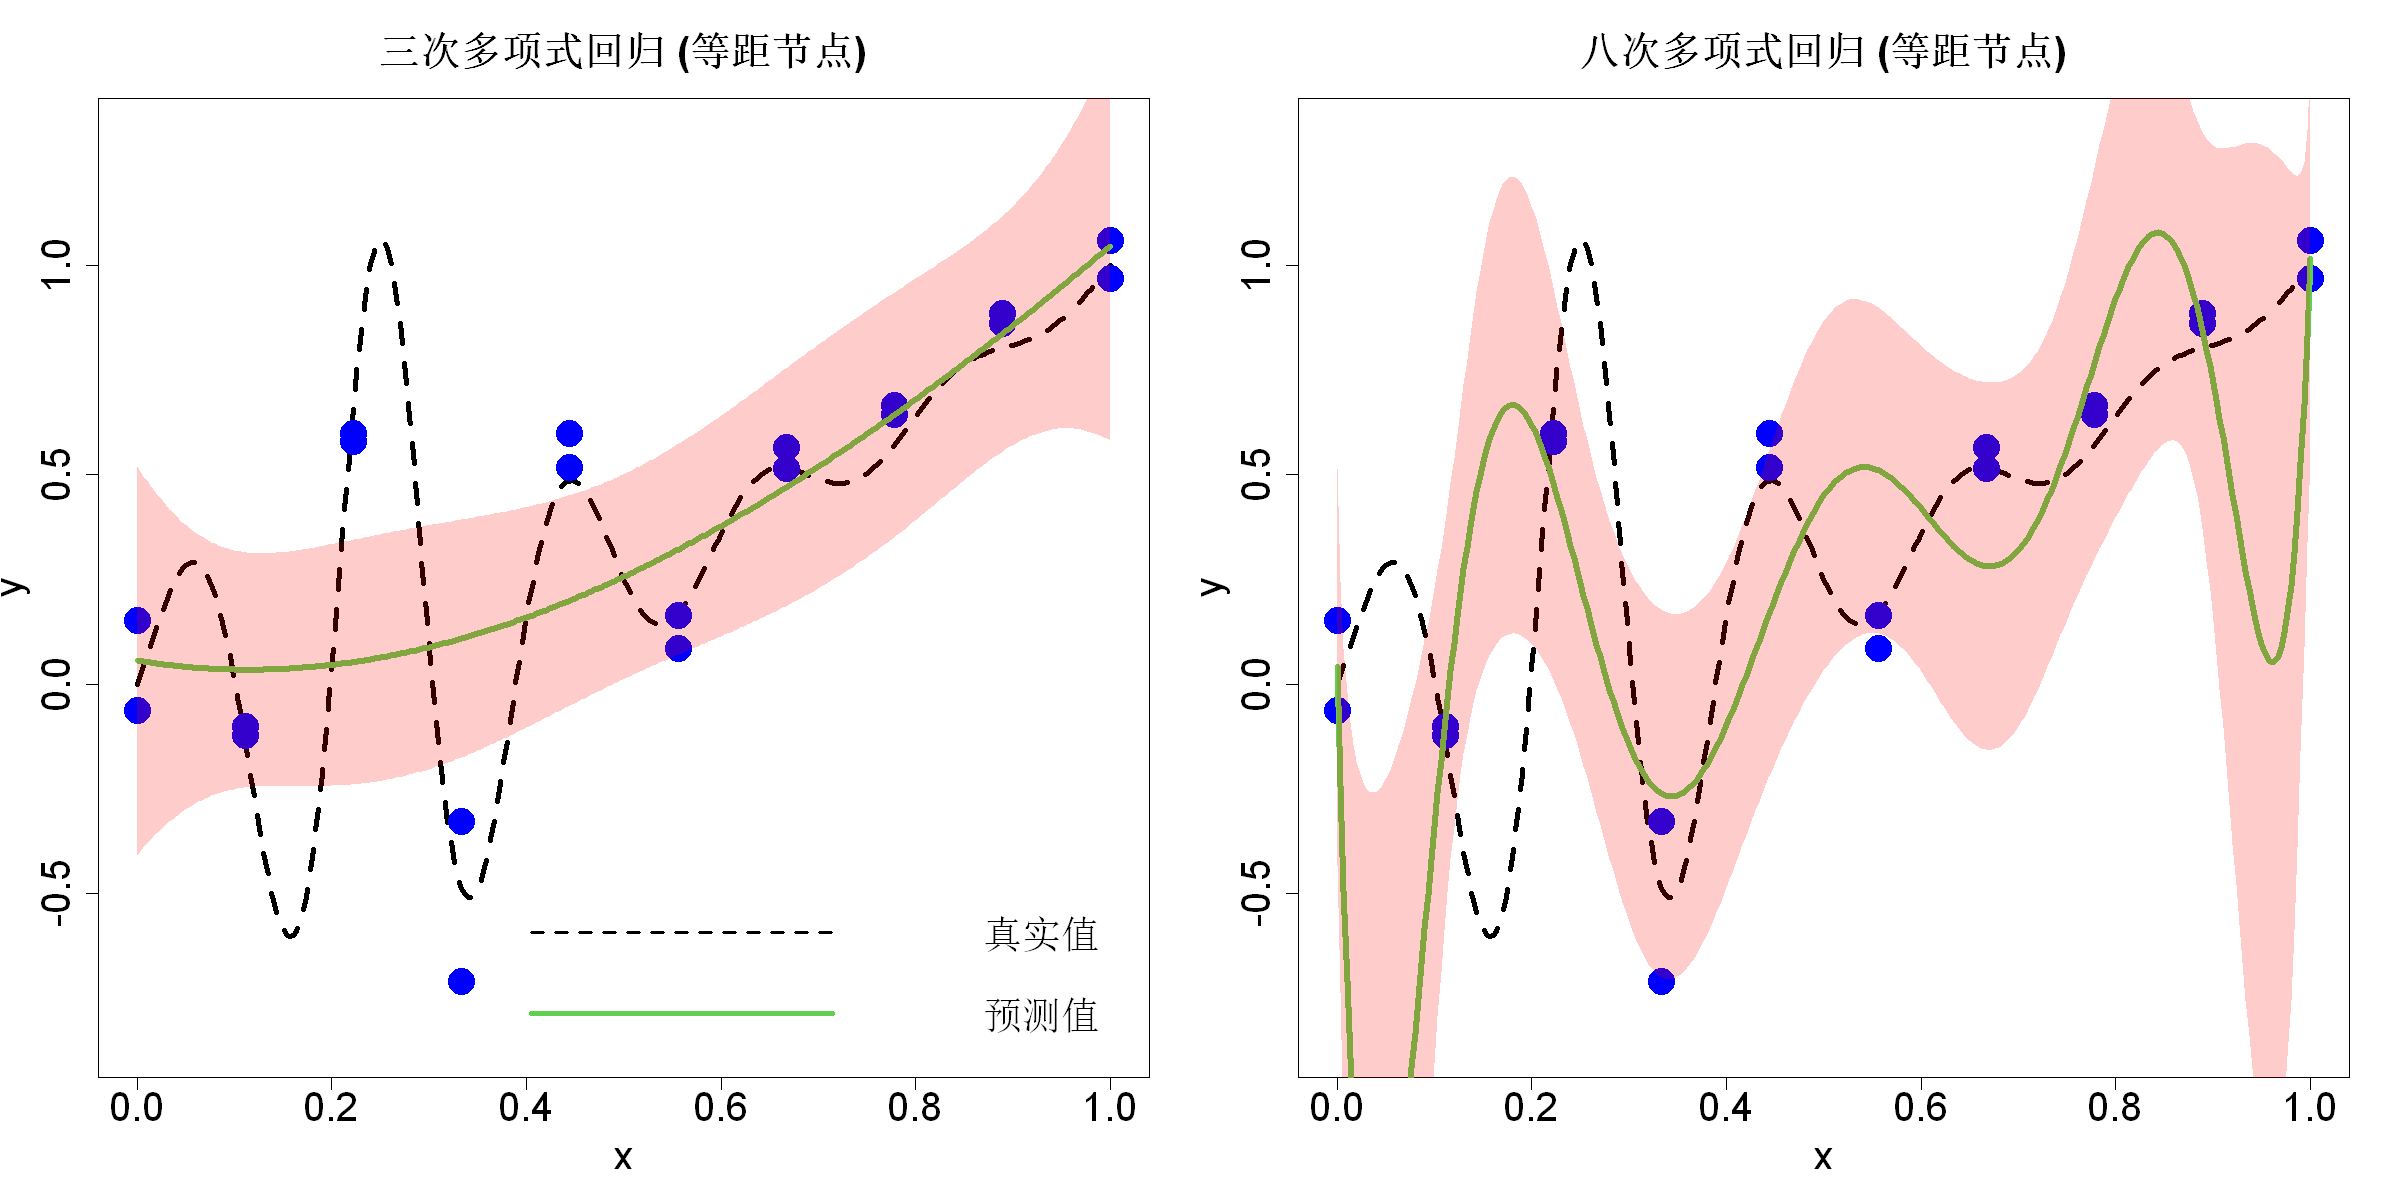

In [6]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
D=((1:n)-1)/(n-1)
r=2
D=rep(D,r)
set.seed(1)
e=rnorm(n*r,sd=.1)
y=f(D)+e

plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="三次多项式回归 (等距节点)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
i=3
pred=predict(lm(y~poly(D,i)),newdata=data.frame(D=test),interval="confidence")
lines(test,pred[,1],col=3,lwd=5)
polygon(c(test,rev(test)),c(pred[,2],rev(pred[,3])),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)

plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="八次多项式回归 (等距节点)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
i=8
pred=predict(lm(y~poly(D,i)),newdata=data.frame(D=test),interval="confidence")
lines(test,pred[,1],col=3,lwd=5)
polygon(c(test,rev(test)),c(pred[,2],rev(pred[,3])),col=adjustcolor("red",0.2),border=NA)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$